In [ ]:
import requests

# 下载数据文件
url = "https://ftp.pride.ebi.ac.uk/pride/data/archive/2018/12/PXD011467/merged.results.F115714.mzid.gz"
response = requests.get(url)

filename = "merged.results.F115714.mzid.gz"
with open(filename, "wb") as f:
    f.write(response.content)

In [ ]:
import gzip

with gzip.open("merged.results.F115714.mzid.gz", "rb") as f_in:
    with open("merged.results.F115714.mzid", "wb") as f_out:
        f_out.write(f_in.read())

In [ ]:
!pip install pyteomics pandas matplotlib enrichrpy
import pandas as pd
import numpy as np
from pyteomics import mzid
import matplotlib.pyplot as plt

In [ ]:
with mzid.read("merged.results.F115714.mzid") as reader:
    peptides = [item for item in reader]

In [ ]:
psms = []
for peptide in peptides:
    for psm in peptide["SpectrumIdentificationItem"]:
        peptide_seq = psm.get("PeptideSequence")
        modifications = psm.get("Modification", [])

        psms.append([
            psm["PeptideEvidenceRef"][0]["start"],
            psm["PeptideEvidenceRef"][0]["end"],
            peptide_seq,
            len(peptide_seq) if peptide_seq else None,
            len(modifications),
            psm["calculatedMassToCharge"],
            psm["experimentalMassToCharge"],
            psm["chargeState"],
            psm.get("Mascot:score", None),
            psm.get("percolator:Q value", None),
            psm.get("percolator:PEP", None)
        ])

df_psms = pd.DataFrame(psms, columns=["Start", "End", "Peptide", "Peptide_Length", "Num_Modifications", "Calculated_MZ", "Experimental_MZ", "Charge", "Mascot_Score", "Percolator_Q_Value", "Percolator_PEP"])
df_psms.head()

,Start,End,Peptide,Peptide_Length,Num_Modifications,Calculated_MZ,Experimental_MZ,Charge,Mascot_Score,Percolator_Q_Value,Percolator_PEP
0,612,618,AGSDGAR,7,1,469.253850,469.2523,2,23.26,0.001254,0.004724
1,698,704,VGGALAR,7,1,474.300604,474.3000,2,19.11,0.002278,0.012286
2,736,742,AMAELAA,7,1,490.773015,490.7719,2,22.89,0.001254,0.005138
3,681,687,NVIIGPA,7,1,494.310636,494.3081,2,40.47,0.000317,0.000090
4,681,687,NVIIGPA,7,1,494.310636,494.3085,2,21.21,0.001445,0.007574


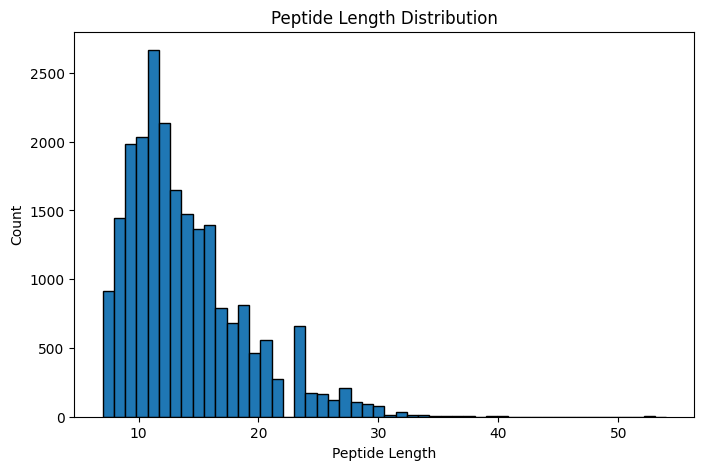

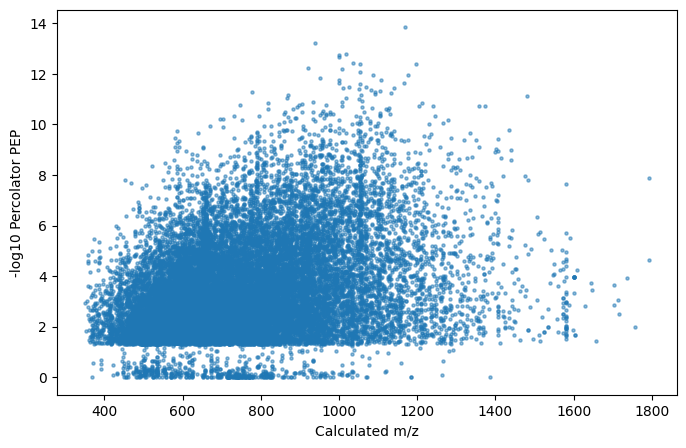

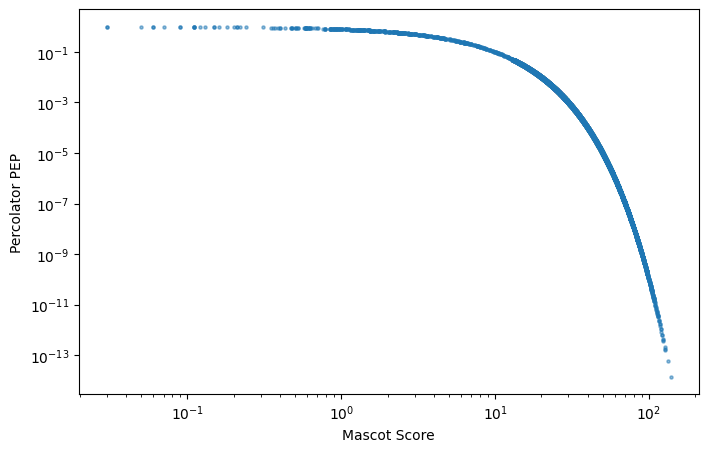

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_psms["Peptide_Length"], bins=50, edgecolor='black')
plt.xlabel("Peptide Length")
plt.ylabel("Count")
plt.title("Peptide Length Distribution")
plt.show()
plt.figure(figsize=(8,5))
plt.scatter(df_psms["Calculated_MZ"], -np.log10(df_psms["Percolator_PEP"]), s=5, alpha=0.5)
plt.xlabel("Calculated m/z")
plt.ylabel("-log10 Percolator PEP")
plt.show()
plt.figure(figsize=(8,5))
plt.scatter(df_psms["Mascot_Score"], df_psms["Percolator_PEP"], s=5, alpha=0.5)
plt.xlabel("Mascot Score")
plt.ylabel("Percolator PEP")
plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from transformers import AutoTokenizer
from transformers import TFAutoModelForSequenceClassification

model_checkpoint = "drive/MyDrive/esm_ecm"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = TFAutoModelForSequenceClassification.from_pretrained(model_checkpoint)

All model checkpoint layers were used when initializing TFEsmForSequenceClassification.

All the layers of TFEsmForSequenceClassification were initialized from the model checkpoint at drive/MyDrive/esm_ecm.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFEsmForSequenceClassification for predictions without further training.


In [ ]:
import tensorflow as tf

# 定义预测函数
def predict_functions(sequence):
    # 对输入序列进行tokenize
    inputs = tokenizer(sequence, return_tensors="tf", padding=True, truncation=True)

    # 进行预测
    outputs = model(inputs)
    probs = tf.sigmoid(outputs.logits)[0]

    return probs[0]

df_psms['esm_result'] = df_psms['Peptide'].apply(predict_functions)

df_psms.head()

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


,Start,End,Peptide,Peptide_Length,Num_Modifications,Calculated_MZ,Experimental_MZ,Charge,Mascot_Score,Percolator_Q_Value,Percolator_PEP,esm_result
0,612,618,AGSDGAR,7,1,469.253850,469.2523,2,23.26,0.001254,0.004724,"tf.Tensor(0.5200511, shape=(), dtype=float32)"
1,698,704,VGGALAR,7,1,474.300604,474.3000,2,19.11,0.002278,0.012286,"tf.Tensor(0.5194481, shape=(), dtype=float32)"
2,736,742,AMAELAA,7,1,490.773015,490.7719,2,22.89,0.001254,0.005138,"tf.Tensor(0.5094828, shape=(), dtype=float32)"
3,681,687,NVIIGPA,7,1,494.310636,494.3081,2,40.47,0.000317,0.000090,"tf.Tensor(0.50297457, shape=(), dtype=float32)"
4,681,687,NVIIGPA,7,1,494.310636,494.3085,2,21.21,0.001445,0.007574,"tf.Tensor(0.50297457, shape=(), dtype=float32)"


In [ ]:
high_psms = df_psms[df_psms['esm_result']>0.6]
high_psms

,Start,End,Peptide,Peptide_Length,Num_Modifications,Calculated_MZ,Experimental_MZ,Charge,Mascot_Score,Percolator_Q_Value,Percolator_PEP,esm_result
14020,995,1014,GPPGPMGPPGLAGPPGESGR,20,1,697.031583,697.0327,3,56.33,0.000000,2.325990e-06,"tf.Tensor(0.6381506, shape=(), dtype=float32)"
17125,935,958,GSPGADGPAGAPGTPGPQGIAGQR,24,1,1189.111730,1189.1132,2,52.57,0.000000,5.537020e-06,"tf.Tensor(0.6714243, shape=(), dtype=float32)"
17646,223,241,LQNLDALTNLTVLSMQSNR,19,1,1218.165090,1218.1664,2,39.16,0.000317,1.214630e-04,"tf.Tensor(0.6359457, shape=(), dtype=float32)"
18721,1892,1911,DLTATEVQSETALLTWRPPR,20,1,647.855089,647.8544,4,26.56,0.000490,2.210540e-03,"tf.Tensor(0.6289759, shape=(), dtype=float32)"
20092,748,777,GENGVVGPTGPVGAAGPAGPNGPPGPAGSR,30,1,952.494911,952.4871,3,19.73,0.002268,1.065160e-02,"tf.Tensor(0.656472, shape=(), dtype=float32)"
20653,315,337,VSCLGVTDDGMAVATGSWDSFLK,23,3,1008.847079,1008.8443,3,107.17,0.000000,1.917930e-11,"tf.Tensor(0.63269424, shape=(), dtype=float32)"
20654,315,337,VSCLGVTDDGMAVATGSWDSFLK,23,3,1008.847079,1008.8465,3,32.65,0.000317,5.426610e-04,"tf.Tensor(0.63269424, shape=(), dtype=float32)"
21409,1130,1157,EVTSDSGSIVVSGLTPGVEYVYTIQVLR,28,1,1091.590431,1091.5850,3,16.93,0.003022,2.026840e-02,"tf.Tensor(0.6484807, shape=(), dtype=float32)"
21548,741,768,EHVPQLLLLLTAGQSEDSYLQAANALTR,28,1,1119.276934,1119.2726,3,67.76,0.000000,1.675930e-07,"tf.Tensor(0.616591, shape=(), dtype=float32)"
21549,741,768,EHVPQLLLLLTAGQSEDSYLQAANALTR,28,1,1119.276934,1119.2762,3,17.84,0.002554,1.644420e-02,"tf.Tensor(0.616591, shape=(), dtype=float32)"


In [ ]:
import requests
import json
import pandas as pd

def get_uniprot_id(peptide):
    # Unipept API URL
    UNIPEPT_API_URL = "https://api.unipept.ugent.be/api/v1/pept2prot"
    # 发送POST请求,获取肽段对应的分类信息
    response = requests.post(UNIPEPT_API_URL, data={"input": peptide})
    if response.status_code == 200:
        # 解析JSON结果
        results = json.loads(response.text)

        if results:
            # 提取UniProt ID
            uniprot_id = results[0].get("uniprot_id", None)
            return uniprot_id

    return None

# 示例用法
high_psms['uniprot_id'] = high_psms['Peptide'].apply(get_uniprot_id)

# 去除没有找到UniProt ID的行
high_psms = high_psms[high_psms['uniprot_id'].notnull()]

# 获取唯一的UniProt ID列表
uniprot_ids = high_psms['uniprot_id'].unique().tolist()
print(uniprot_ids)

['P02454', 'C0HJP5', 'Q3T0W4', 'P24821', 'P08123', 'P62871', 'P02751', 'P12111', 'Q9Y6C2', 'P12109']


<ipython-input-24-25d877c1f92b>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_psms['uniprot_id'] = high_psms['Peptide'].apply(get_uniprot_id)


In [ ]:
def analyze_single_aa_importance(sequence, model_predict_func, mask_token='<mask>'):
    # 原始序列的预测结果
    original_prediction = model_predict_func(sequence)

    # 存储每个位置的重要性得分
    importance_scores = []

    for i in range(len(sequence)):
        # 屏蔽第i个氨基酸
        masked_sequence = sequence[:i] + mask_token + sequence[i+1:]

        # 屏蔽后的预测结果
        masked_prediction = model_predict_func(masked_sequence)

        # 计算重要性得分(对于二元预测,我们可以使用预测概率的差值)
        importance_score = abs(original_prediction - masked_prediction)

        importance_scores.append(importance_score)

    return importance_scores

In [ ]:
def analyze_sequence_variants(sequence, model_predict_func, num_variants_per_position=1):
    # 原始序列的预测结果
    original_prediction = model_predict_func(sequence)

    # 存储每个变异的影响分数
    mutation_effects = {}

    for i in range(len(sequence)):
        for _ in range(num_variants_per_position):
            # 随机选择一个不同于原始氨基酸的新氨基酸
            new_aa = random.choice([aa for aa in amino_acids if aa != sequence[i]])

            # 构建变异序列
            mutated_sequence = sequence[:i] + new_aa + sequence[i+1:]

            # 变异序列的预测结果
            mutated_prediction = model_predict_func(mutated_sequence)

            # 计算变异的影响分数(对于二元预测,我们可以使用预测概率的差值)
            effect_score = abs(original_prediction - mutated_prediction)

            mutation_effects[(i, new_aa)] = effect_score

    return mutation_effects

In [ ]:
def identify_functional_regions(sequence, model_predict_func, window_size=10, step_size=1):
    # 存储每个位置的功能区域得分
    region_scores = []

    for i in range(0, len(sequence) - window_size + 1, step_size):
        # 提取子序列
        subsequence = sequence[i:i+window_size]

        # 获取子序列的预测结果
        subsequence_prediction = model_predict_func(subsequence)

        # 计算子序列的功能区域得分(对于二元预测,我们可以直接使用预测概率)
        region_score = subsequence_prediction

        region_scores.append(region_score)

    return region_scores

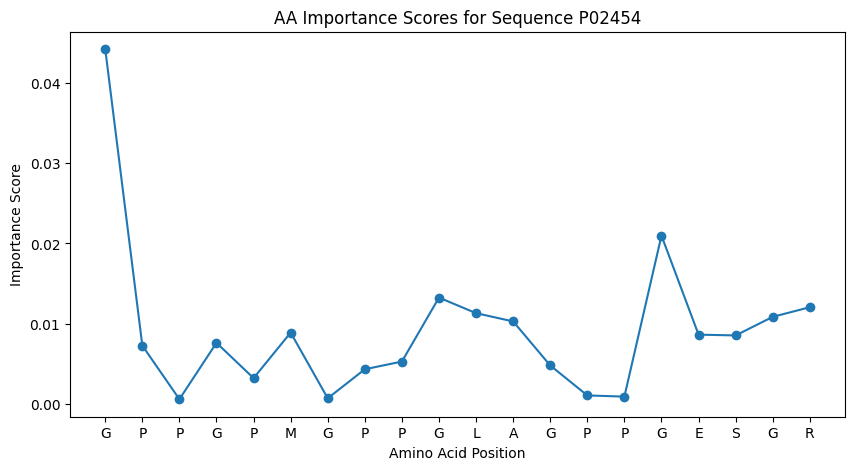

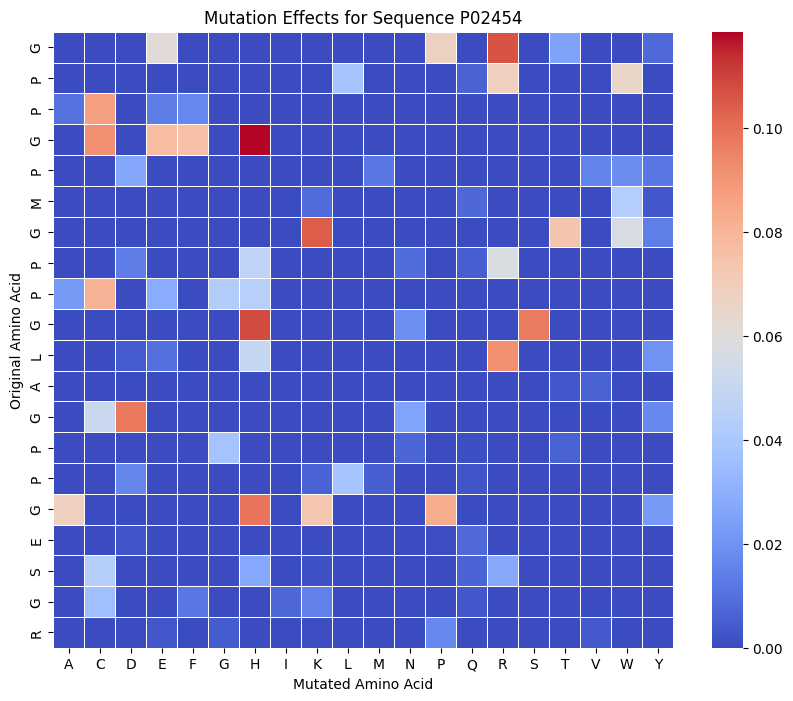

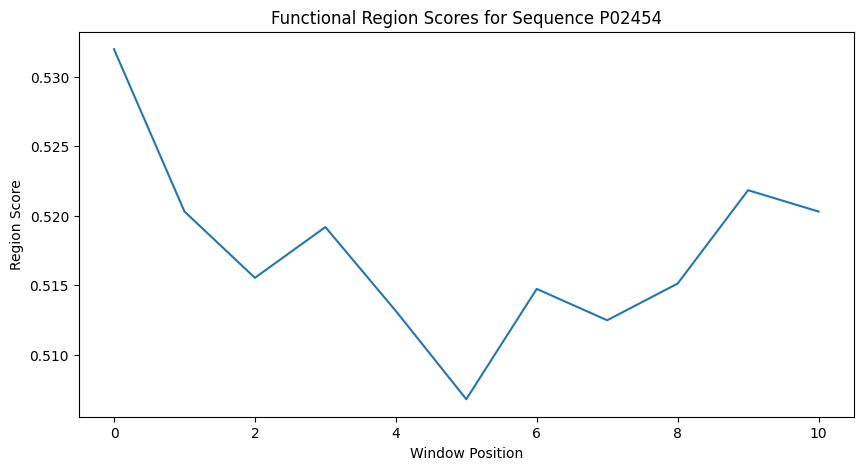

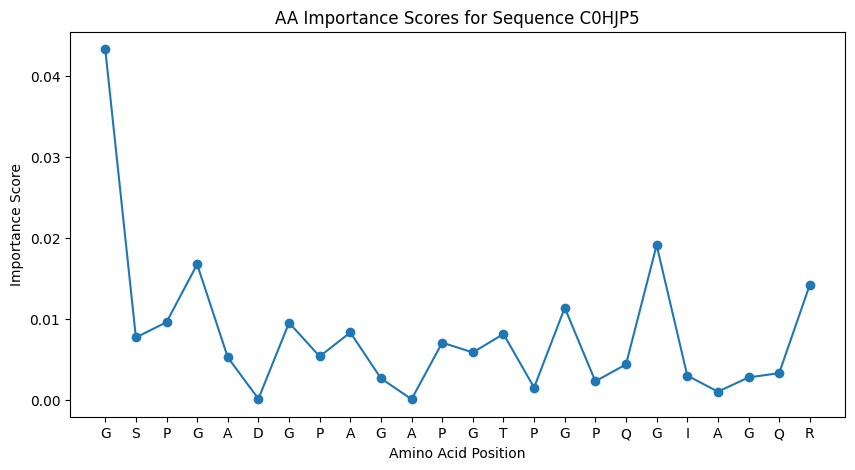

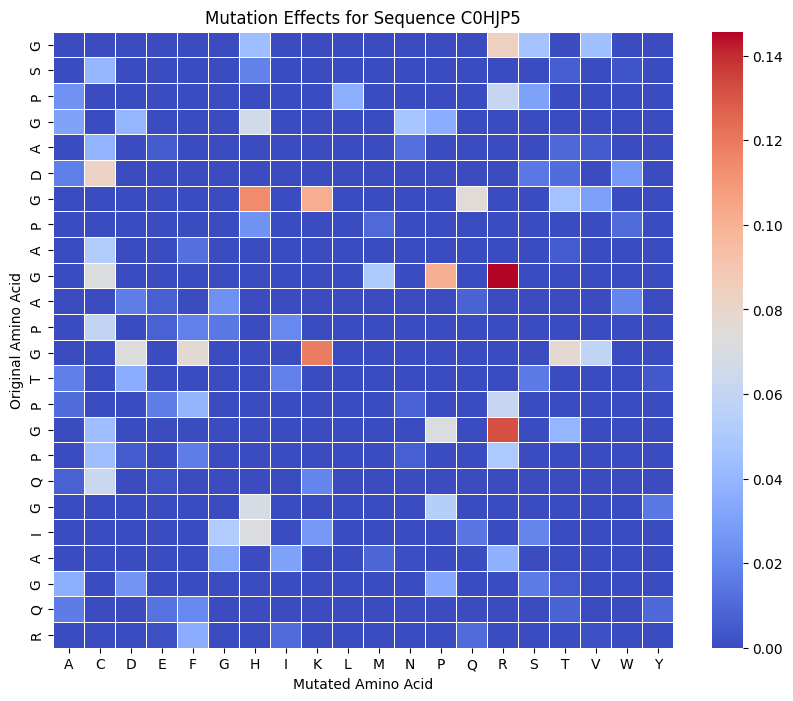

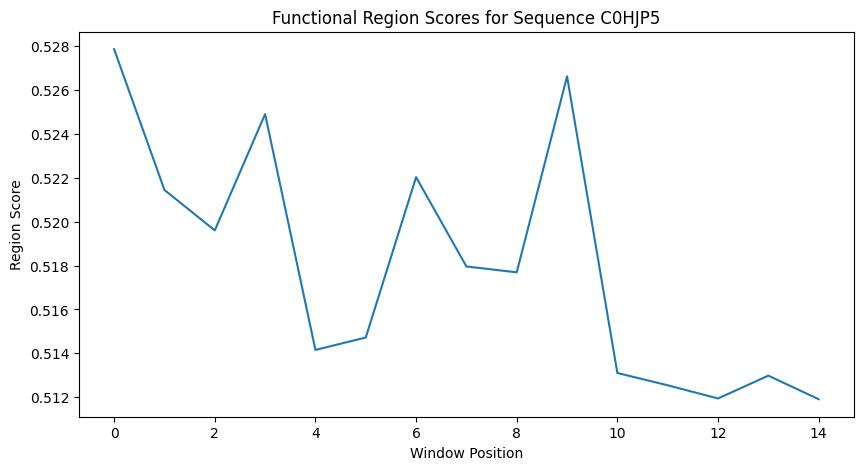

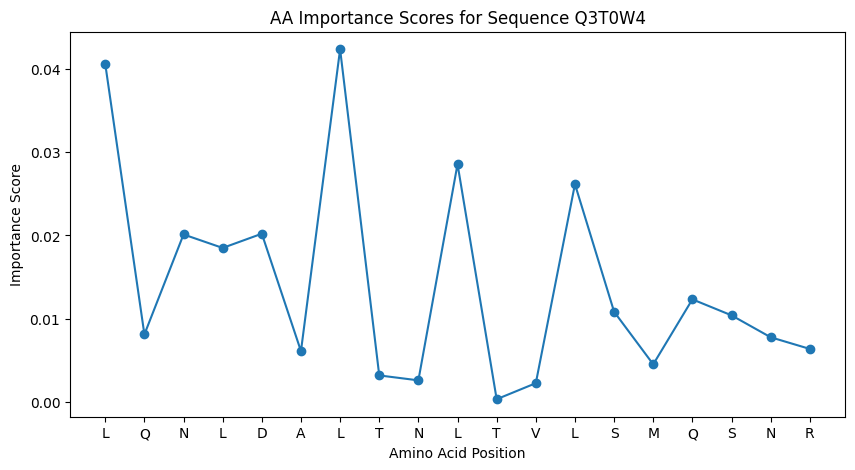

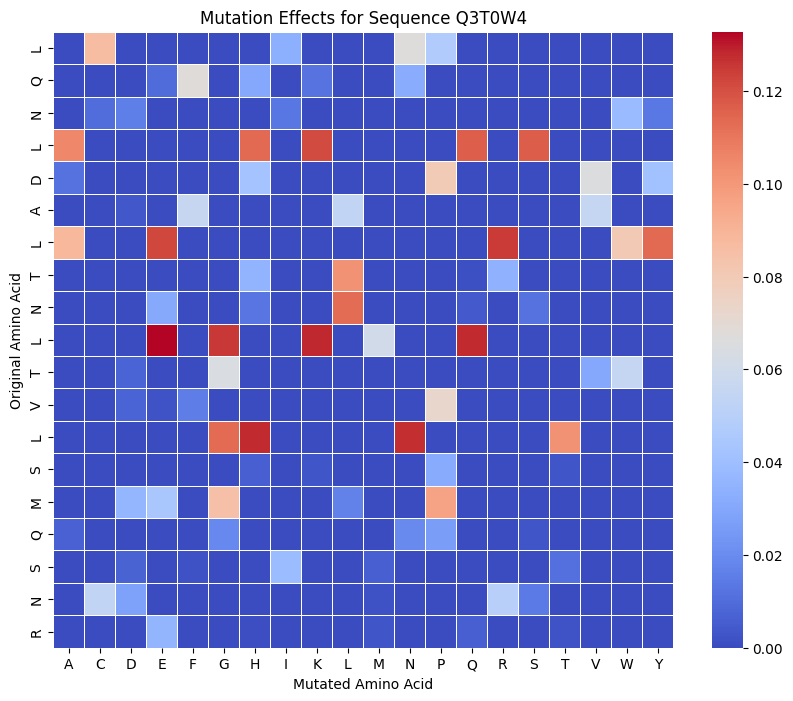

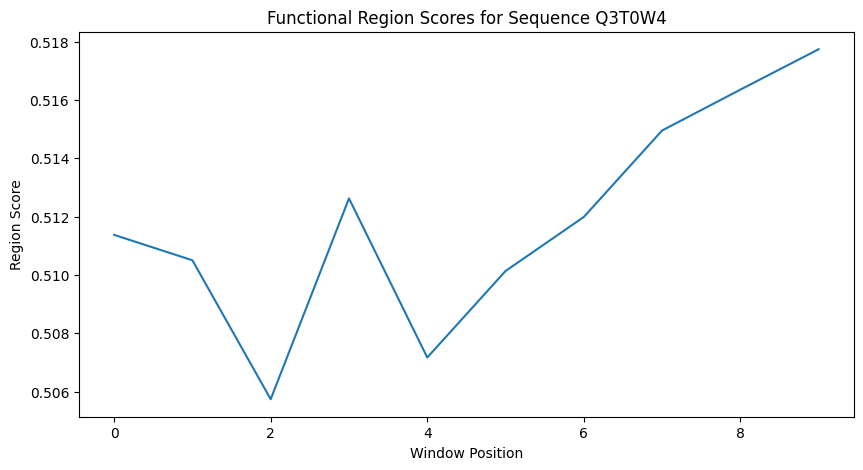

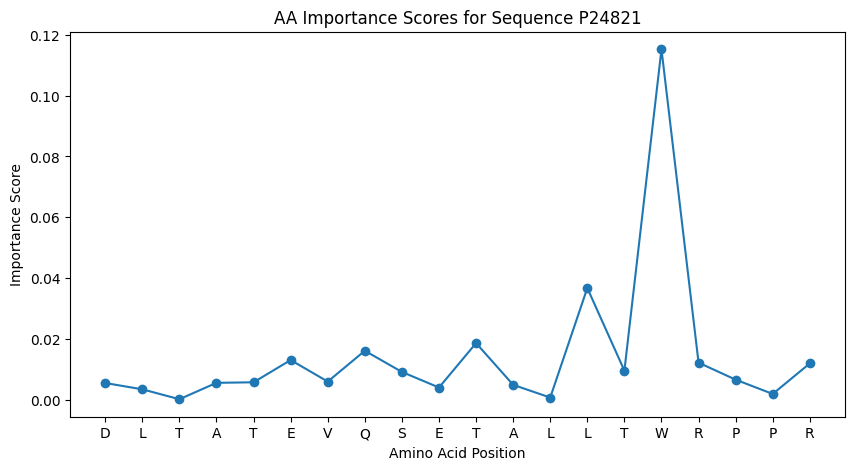

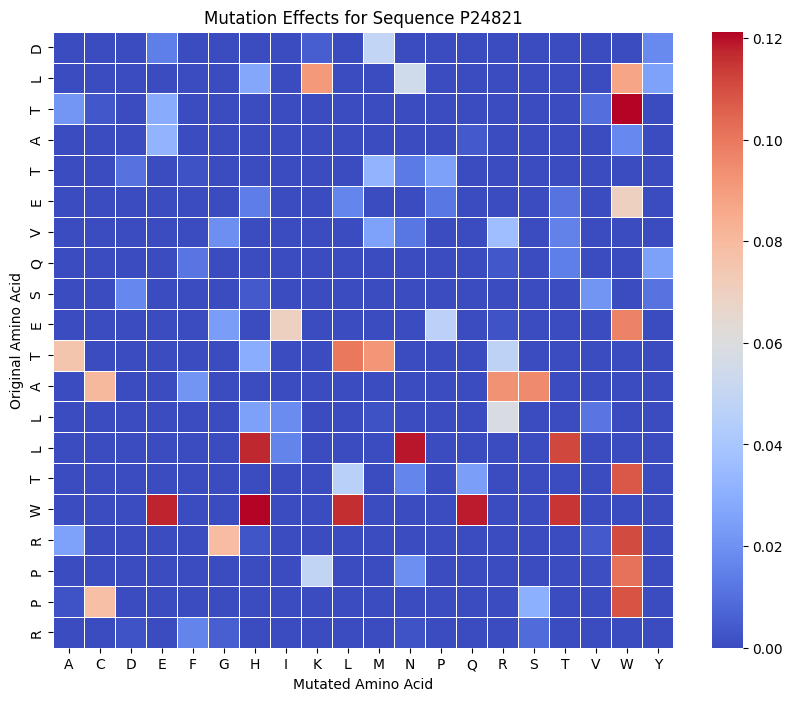

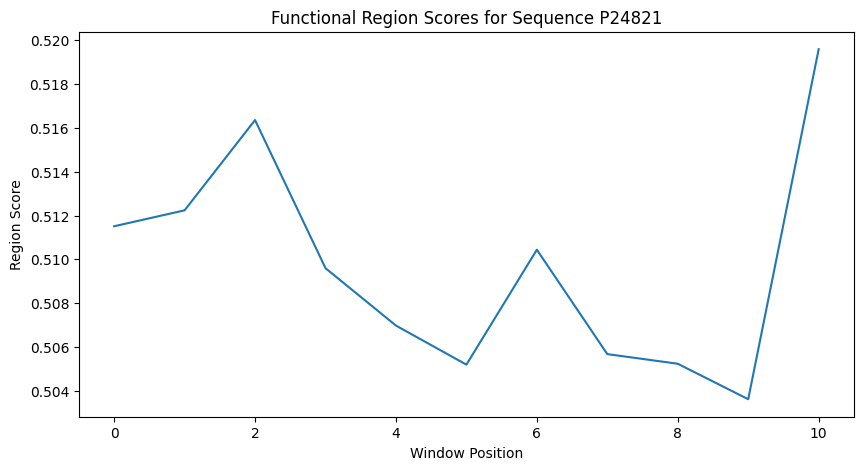

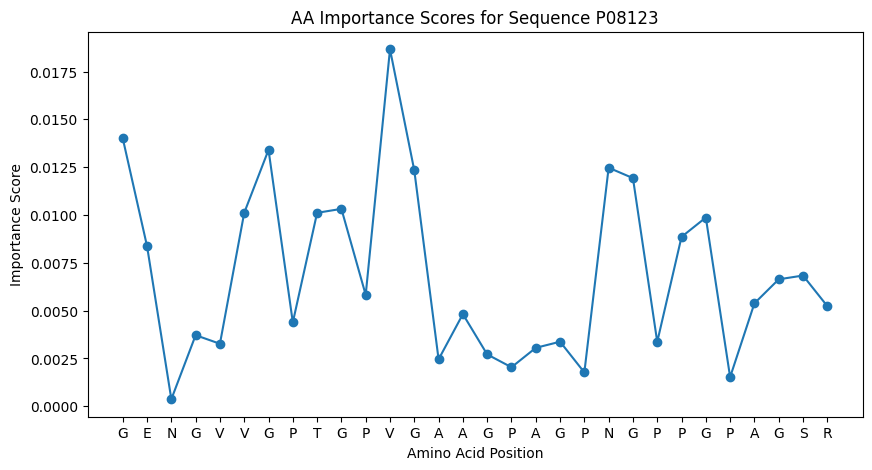

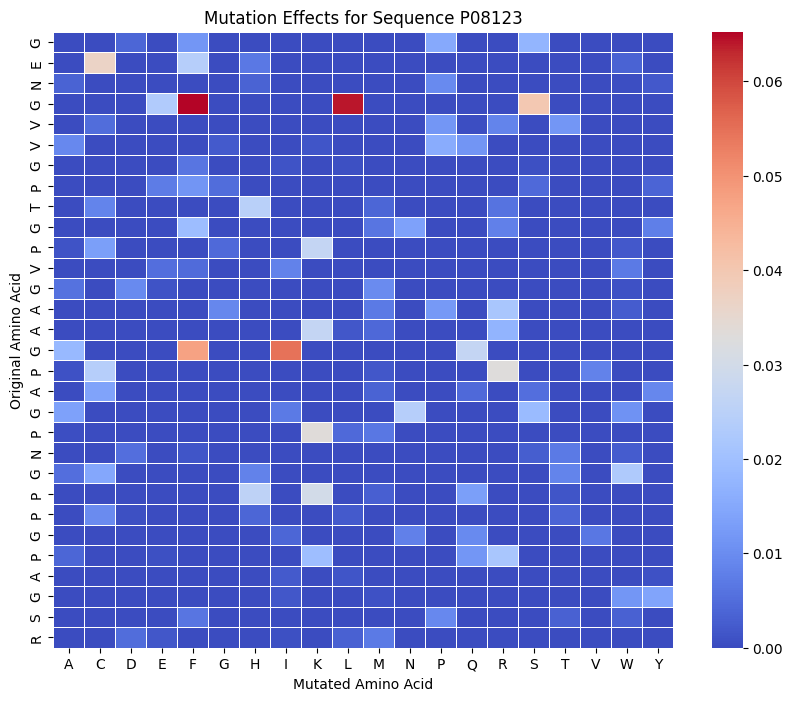

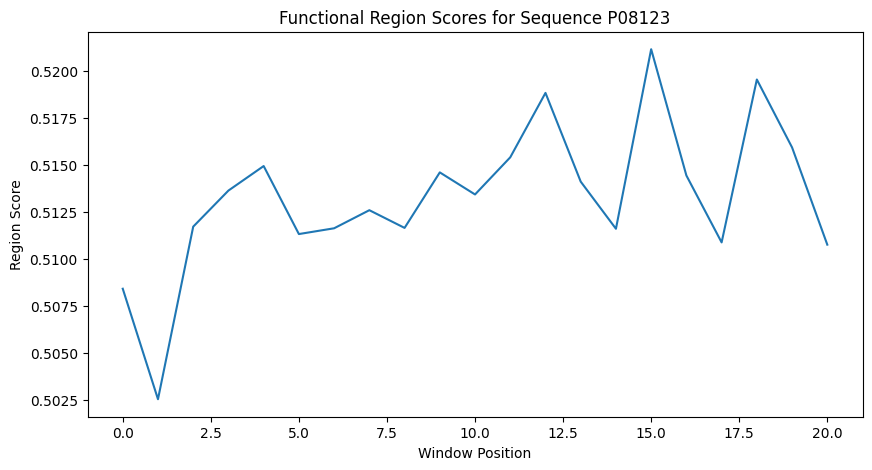

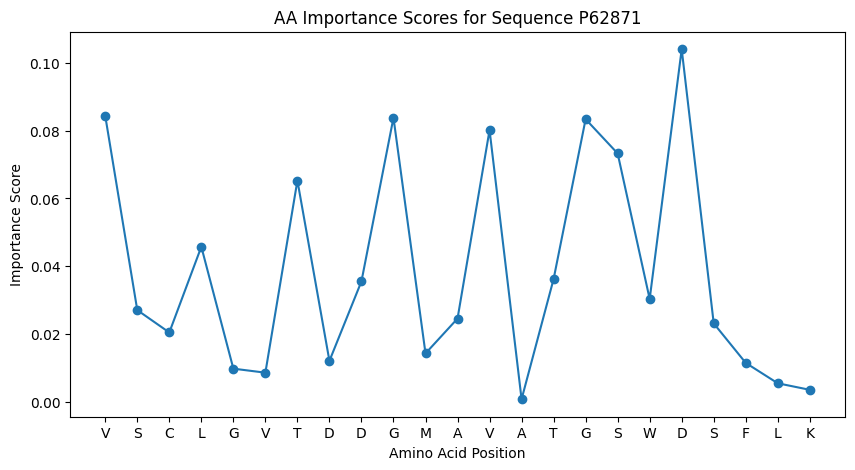

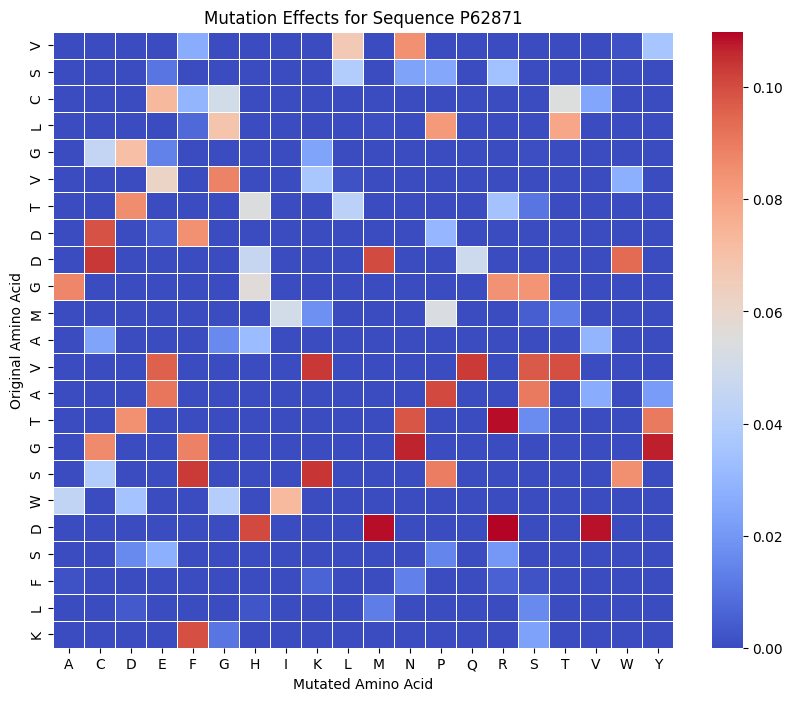

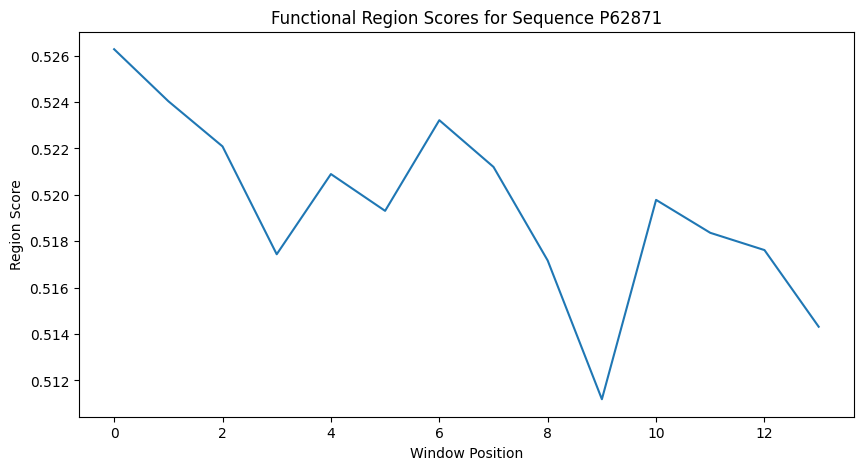

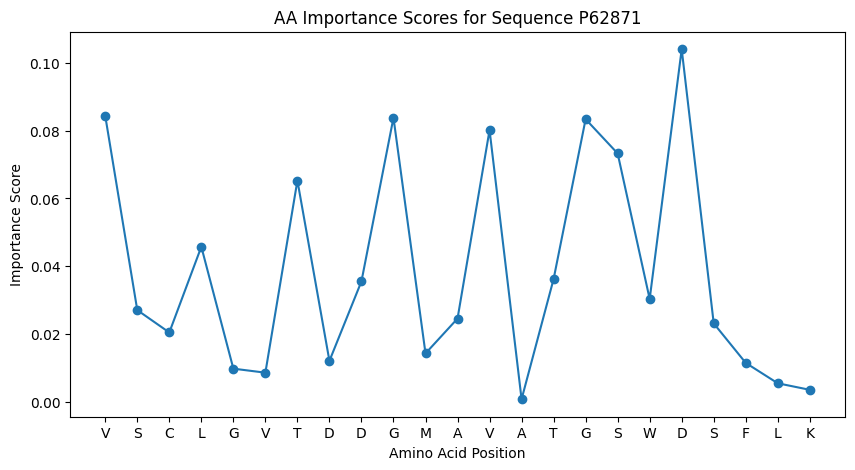

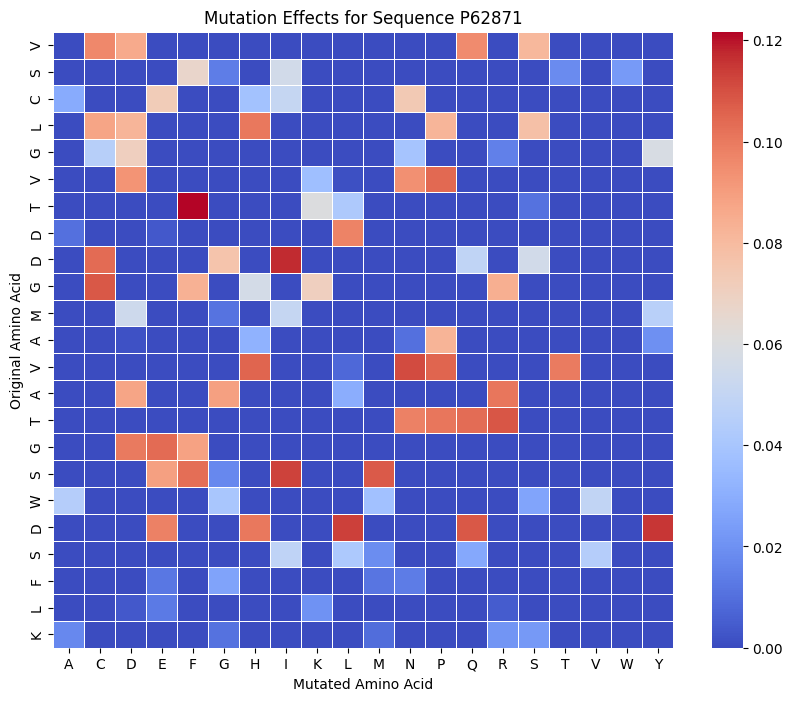

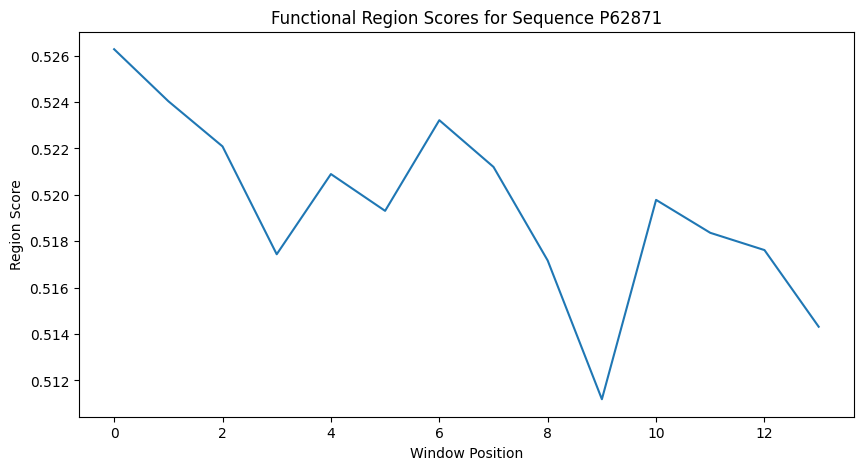

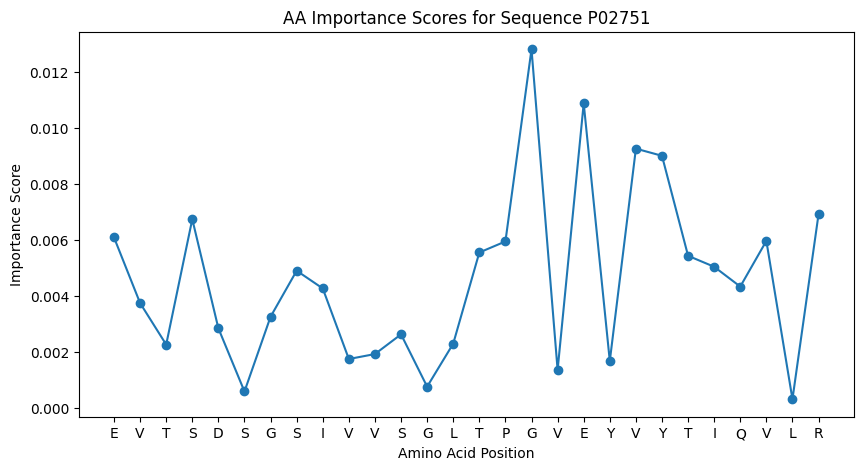

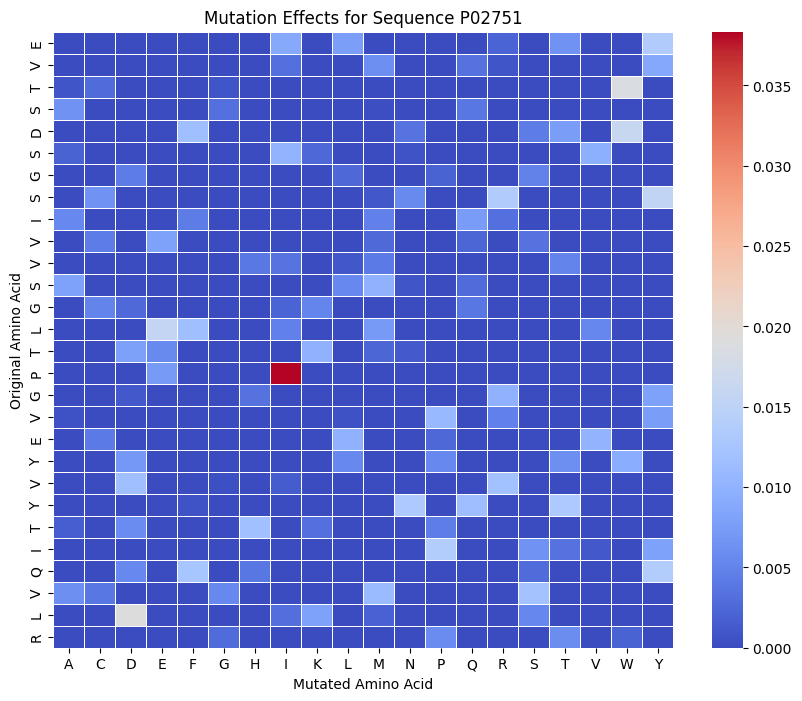

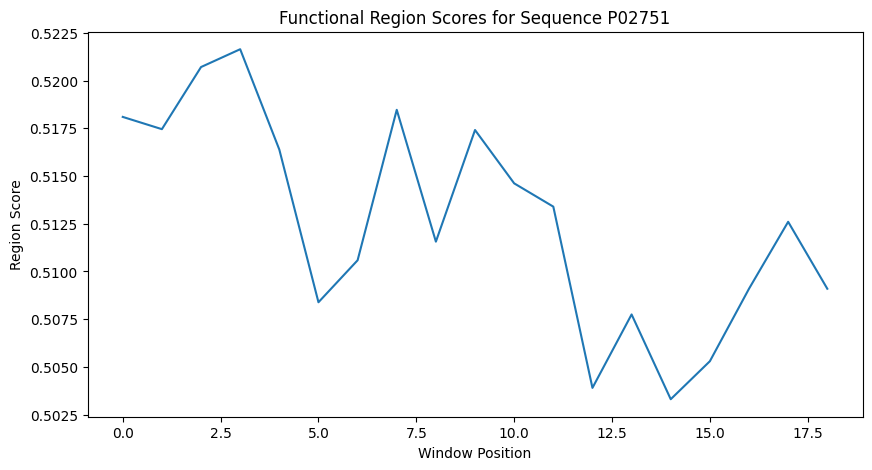

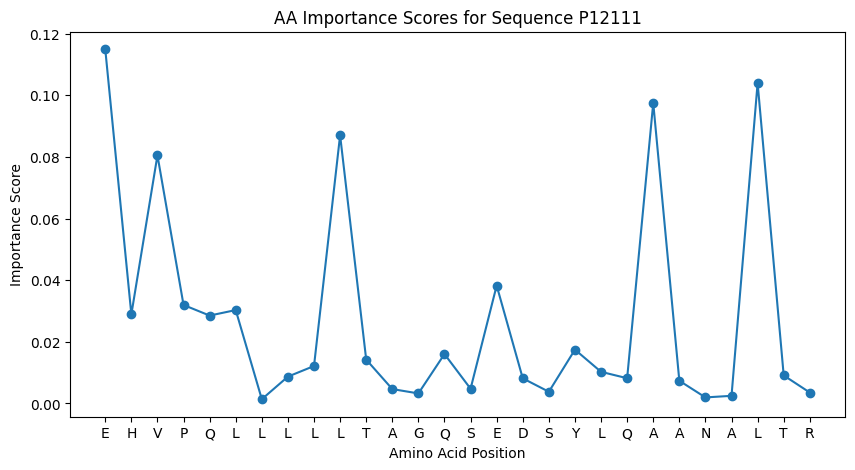

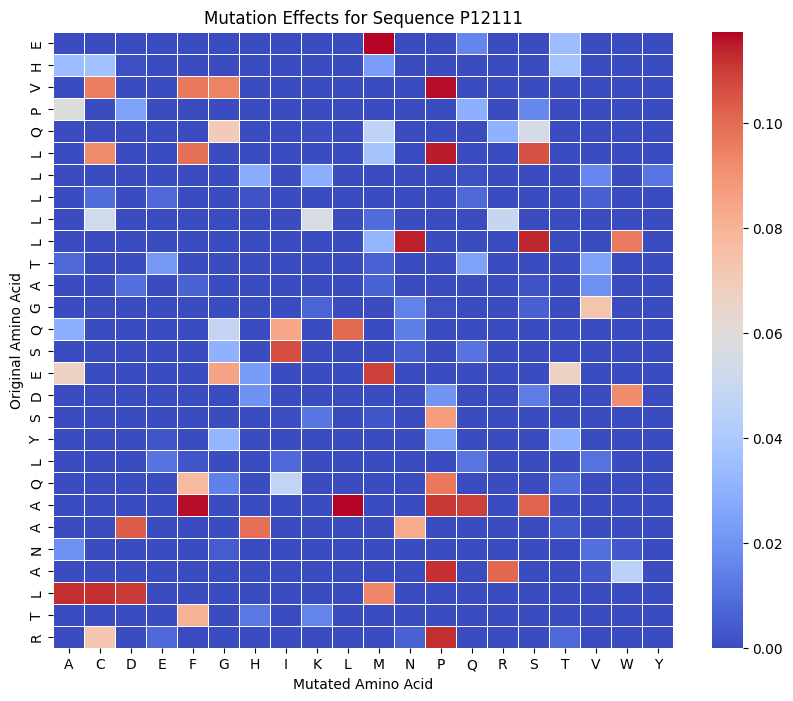

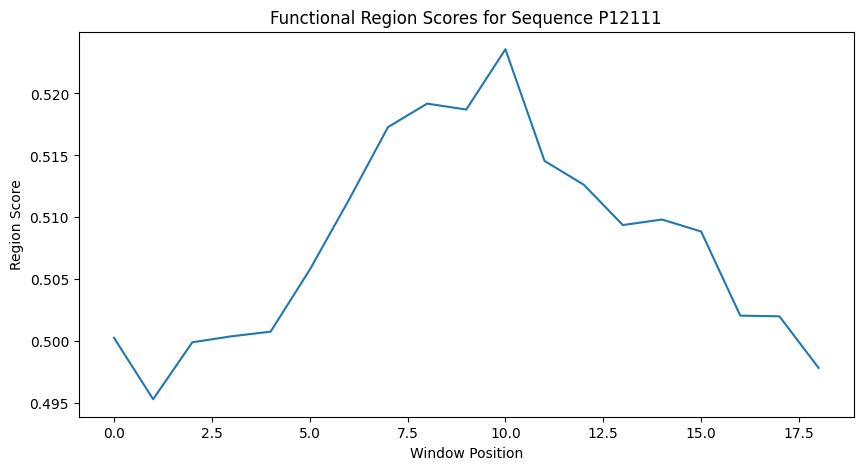

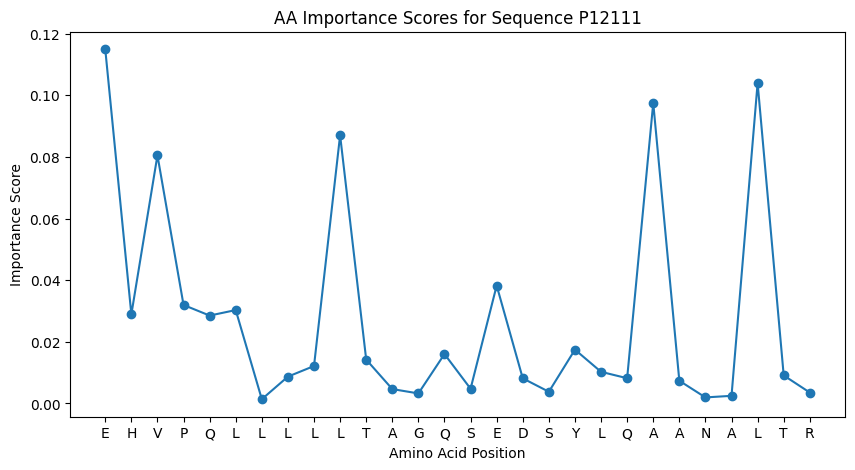

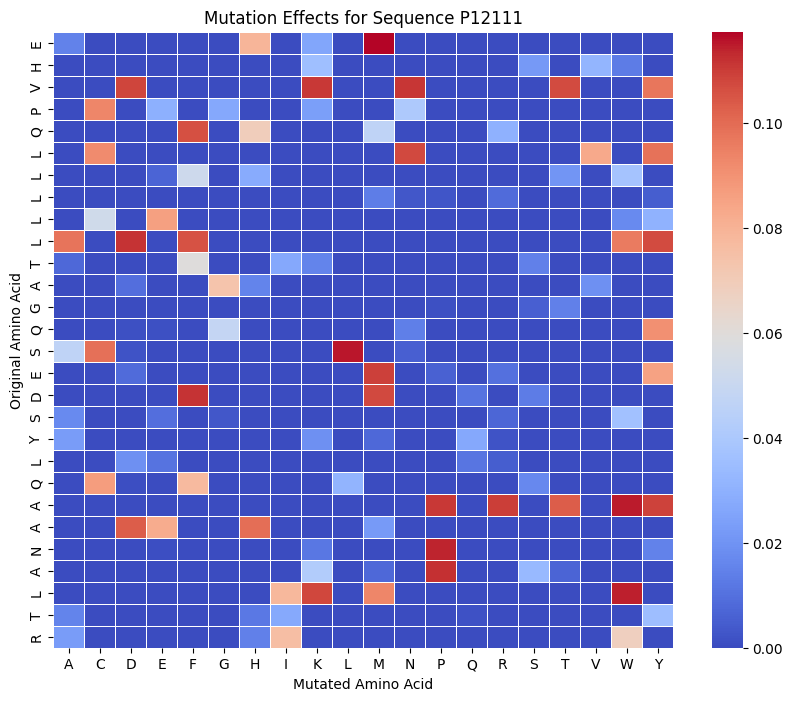

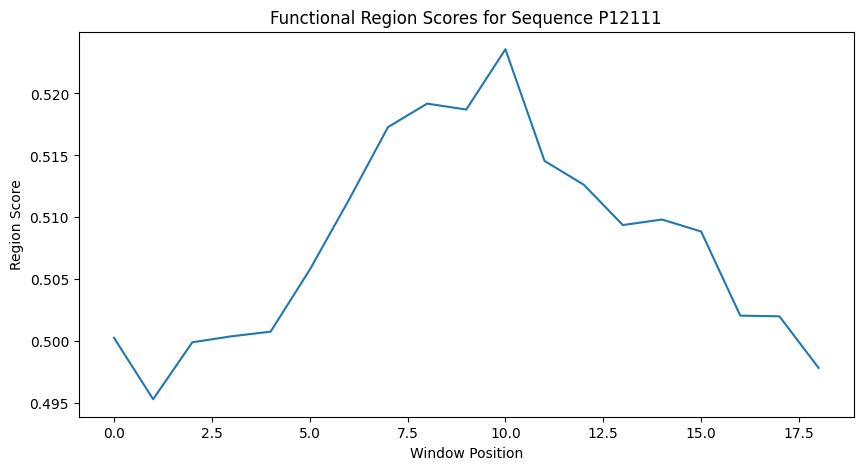

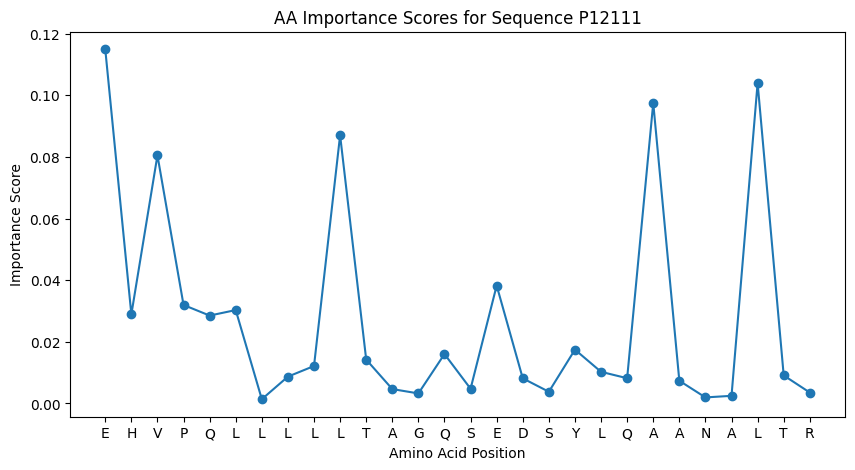

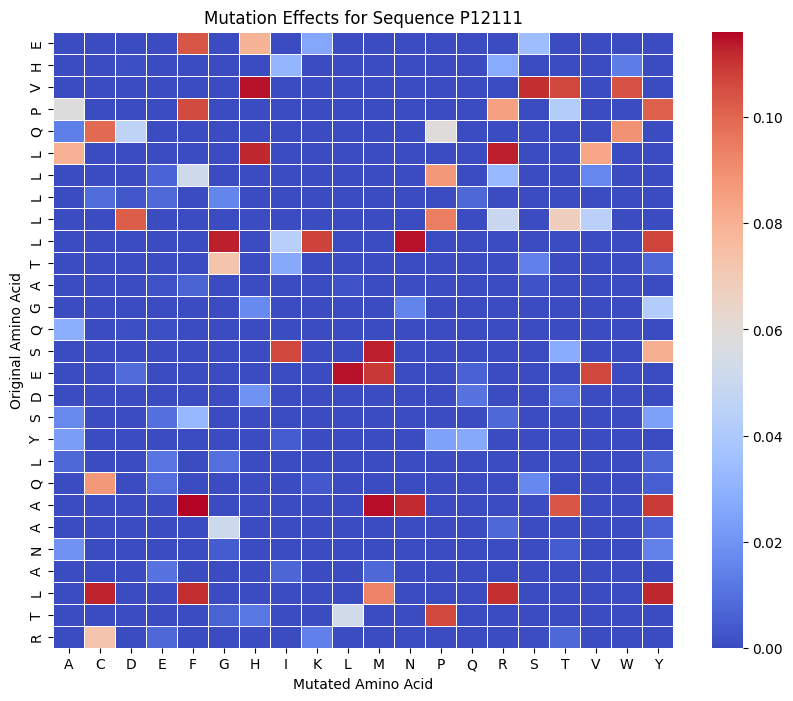

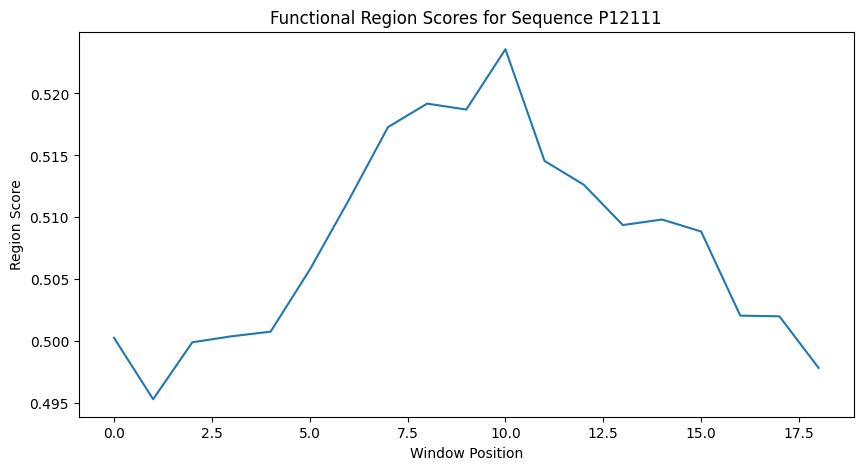

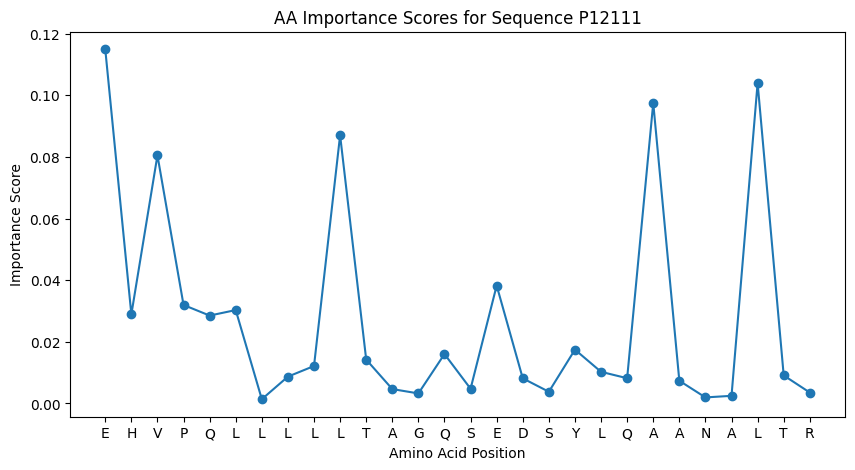

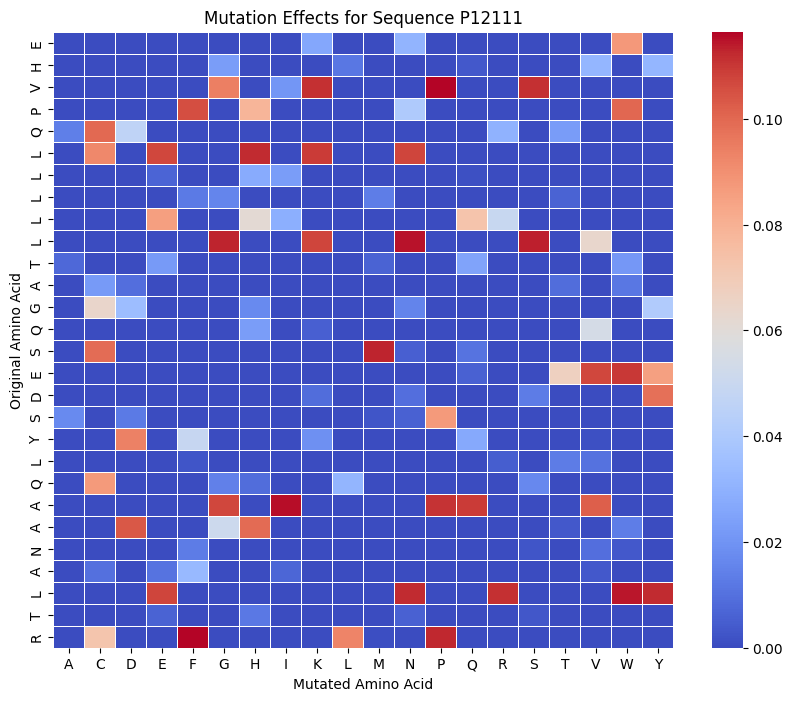

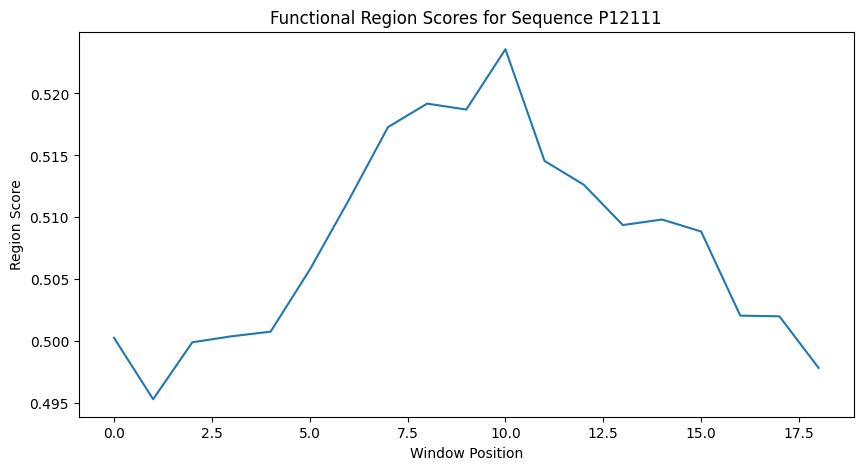

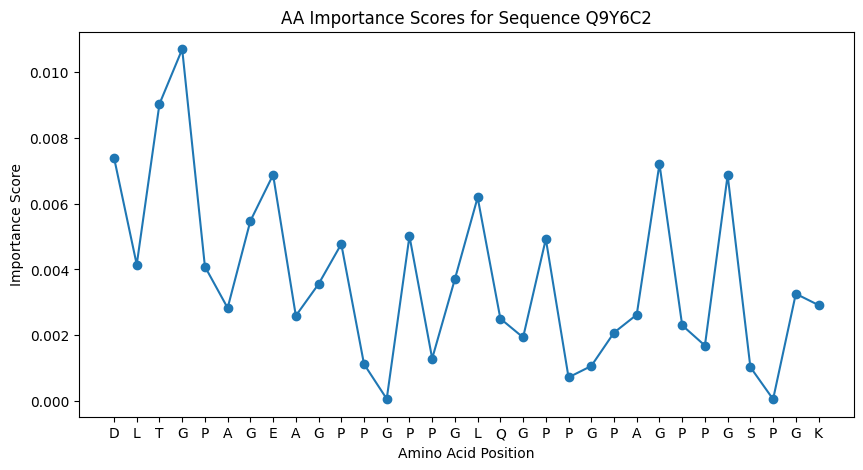

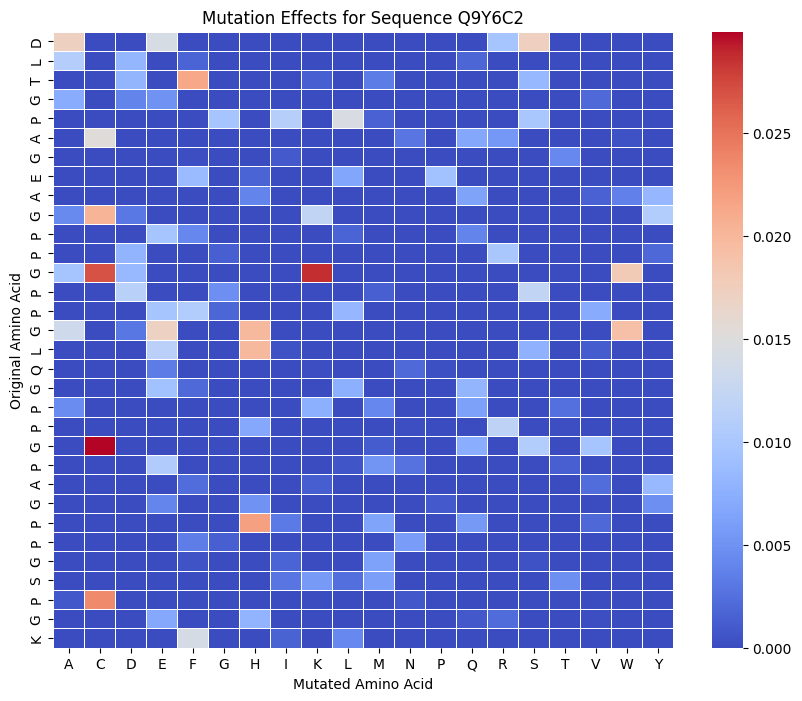

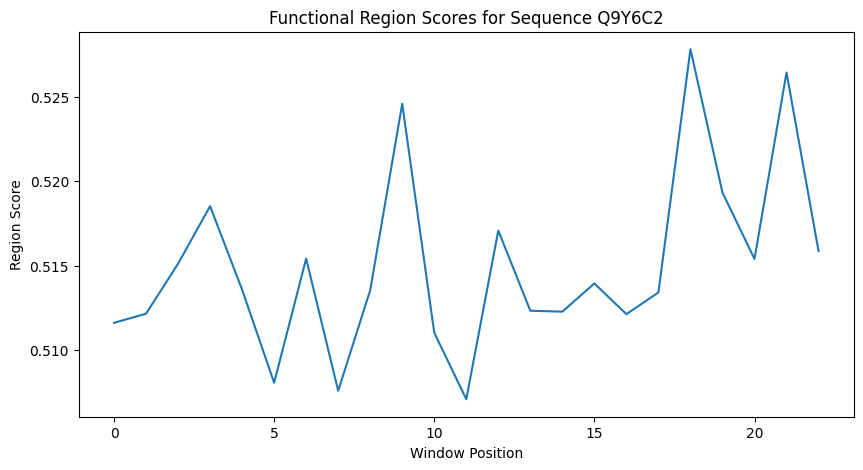

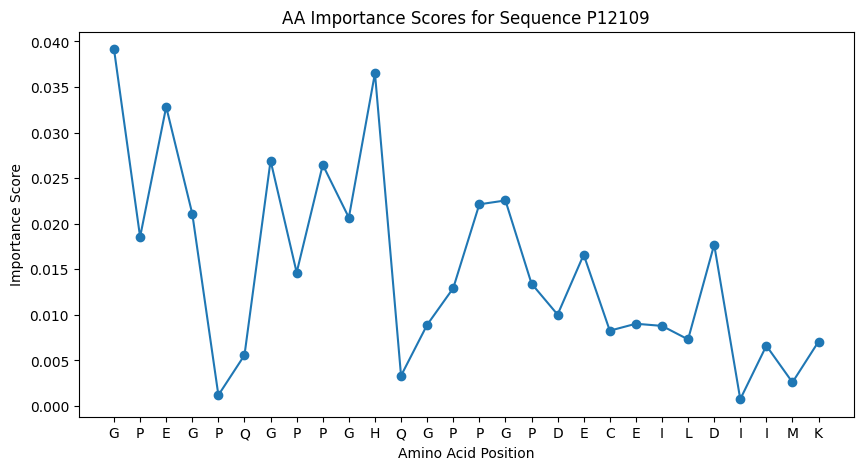

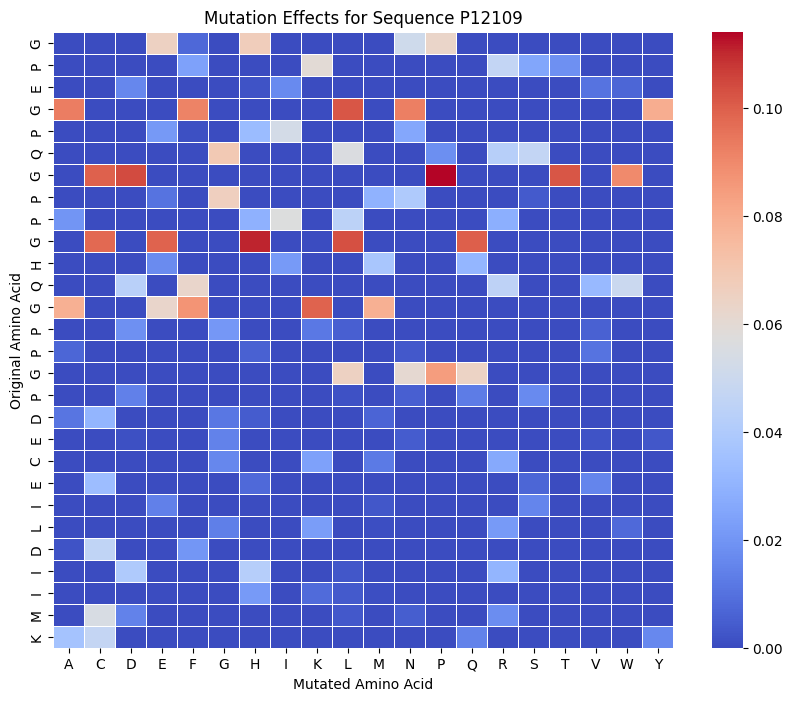

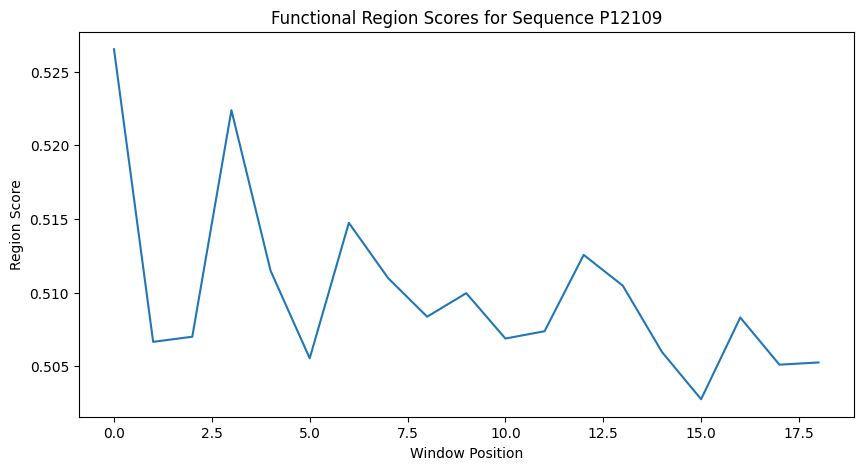

In [ ]:
import random
import matplotlib.pyplot as plt
import seaborn as sns

amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

def interpret_sequence(sequence, model_predict_func):
    # 单个氨基酸重要性分析
    aa_importance_scores = analyze_single_aa_importance(sequence, model_predict_func)

    # 序列变异影响评估
    mutation_effects = analyze_sequence_variants(sequence, model_predict_func, num_variants_per_position=5)

    # 功能区域识别
    region_scores = identify_functional_regions(sequence, model_predict_func, window_size=10, step_size=1)

    return aa_importance_scores, mutation_effects, region_scores

# 对高ESM分数的序列进行可解释性分析
for index, row in high_psms.iterrows():
    sequence = row['Peptide']
    idx = row['uniprot_id']
    aa_importance_scores, mutation_effects, region_scores = interpret_sequence(sequence, predict_functions)

    # 可视化单个氨基酸重要性得分
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(sequence)), aa_importance_scores, marker='o')
    plt.xticks(range(len(sequence)), list(sequence))
    plt.xlabel('Amino Acid Position')
    plt.ylabel('Importance Score')
    plt.title(f'AA Importance Scores for Sequence {idx}')
    plt.savefig(f'aa_importance_scores_seq{idx}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 可视化变异影响热图
    mut_scores = [[mutation_effects.get((i, aa), 0) for aa in amino_acids] for i in range(len(sequence))]
    plt.figure(figsize=(10, 8))
    sns.heatmap(mut_scores, cmap='coolwarm', linewidths=0.5, xticklabels=amino_acids, yticklabels=list(sequence))
    plt.xlabel('Mutated Amino Acid')
    plt.ylabel('Original Amino Acid')
    plt.title(f'Mutation Effects for Sequence {idx}')
    plt.savefig(f'mutation_effects_seq{idx}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 可视化功能区域得分
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(region_scores)), region_scores)
    plt.xlabel('Window Position')
    plt.ylabel('Region Score')
    plt.title(f'Functional Region Scores for Sequence {idx}')
    plt.savefig(f'region_scores_seq{idx}.png', dpi=300, bbox_inches='tight')
    plt.show()